# XGBoost Return Forecasting — All 3 Models

Trains and evaluates three XGBoost models that forecast each coin's **7-day-ahead price** on the test set. Each model is trained independently per coin (8 coins total). Forecasts are evaluated at each 7-day rebalance step and outputs are consumed by CMVO for portfolio optimisation.

---

## Models

### Model 1 — XGBoost Base
- **Features:** 14 lagged close prices
- **Target:** Close price 7 days ahead (direct price prediction)
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (`n_estimators=300`, `max_depth=6`, `lr=0.05`)
- **Output:** `xgboost_forecasts.csv`, RMSE1_normalized.csv`

### Model 2 — XGBoost Features
- **Features:** 14 lagged log returns + 30/60-day rolling volatility (lagged)
- **Target:** Log return 7 days ahead â†’ converted back to price
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (same as Base)
- **Output:** `xgb_feature_forecasts.csv`, `xgb_feature_rmses.csv`

### Model 3 — XGBoost Bayesian Optimised (BO)
- **Features:** 14 lagged close prices + 7-day rolling volatility
- **Target:** Close price 7 days ahead
- **Split:** 60/20/20 train/val/test
- **Hyperparameters:** Tuned with Optuna (30 trials, minimising val RMSE)
- **Output:** `xgboost_forecasts_BO_price_vol.csv`, `xgboost_rmse_summary_BO_price_vol.csv`

---

**Note:** Output CSVs are saved to the notebook's working directory. Tiny-price coins (median < 0.01) are log-transformed before training and inverse-transformed for evaluation.

In [1]:
import os
print(os.listdir("klines csv data/prices_cleaned"))

['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']


## Model 1 — XGBoost Base


Training: ADAUSDT
ADAUSDT RMSE: 0.160889
ADAUSDT Mean Actual Price: 0.528646
ADAUSDT NRMSE (% of mean price): 0.3043%


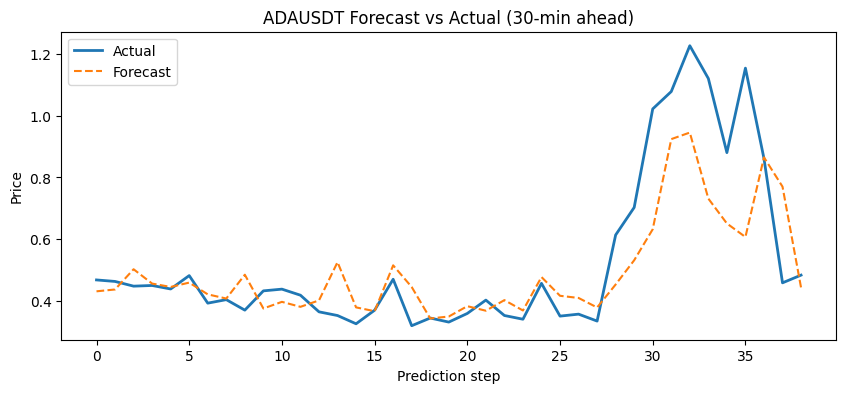


Training: BCHUSDT
BCHUSDT RMSE: 88.484263
BCHUSDT Mean Actual Price: 367.982051
BCHUSDT NRMSE (% of mean price): 0.2405%


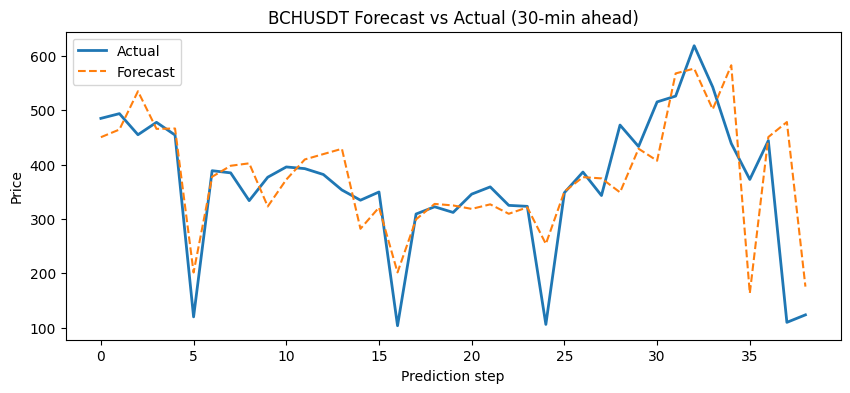


Training: BNBUSDT
BNBUSDT RMSE: 91.077701
BNBUSDT Mean Actual Price: 545.711282
BNBUSDT NRMSE (% of mean price): 0.1669%


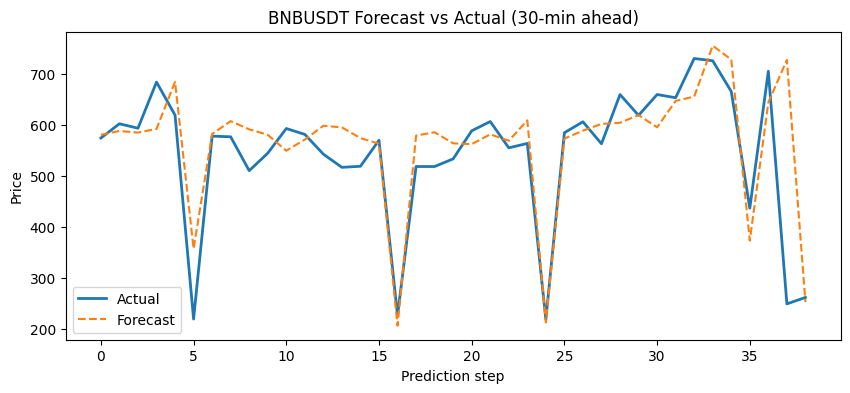


Training: BTCUSDT
BTCUSDT RMSE: 14863.288045
BTCUSDT Mean Actual Price: 64286.045128
BTCUSDT NRMSE (% of mean price): 0.2312%


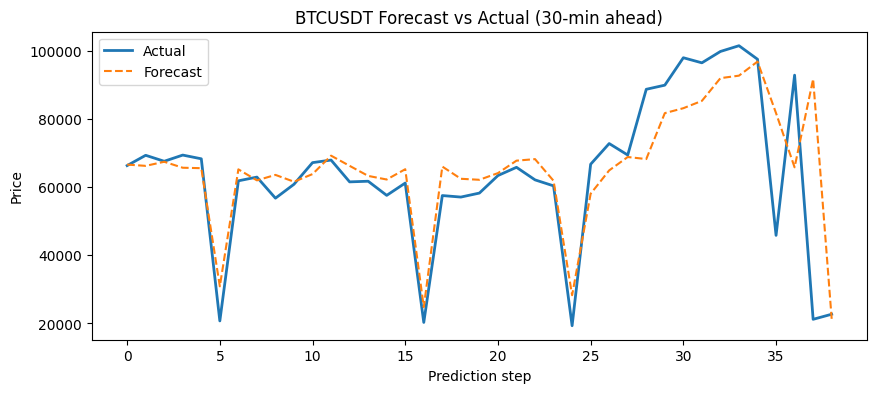


Training: ETHUSDT
ETHUSDT RMSE: 543.011128
ETHUSDT Mean Actual Price: 2851.582564
ETHUSDT NRMSE (% of mean price): 0.1904%


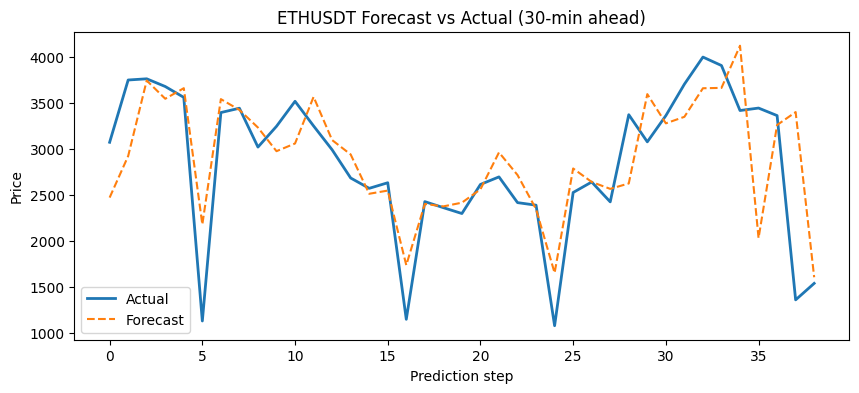


Training: SOLUSDT
SOLUSDT RMSE: 32.606461
SOLUSDT Mean Actual Price: 152.974615
SOLUSDT NRMSE (% of mean price): 0.2131%


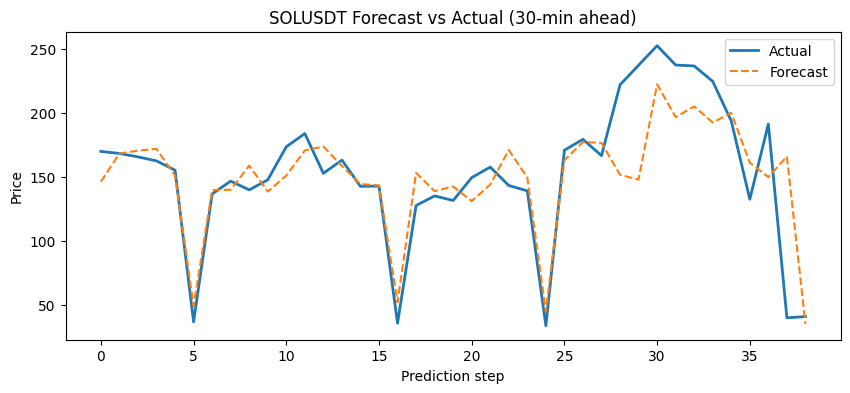


Training: TRXUSDT
TRXUSDT RMSE: 0.056930
TRXUSDT Mean Actual Price: 0.147867
TRXUSDT NRMSE (% of mean price): 0.3850%


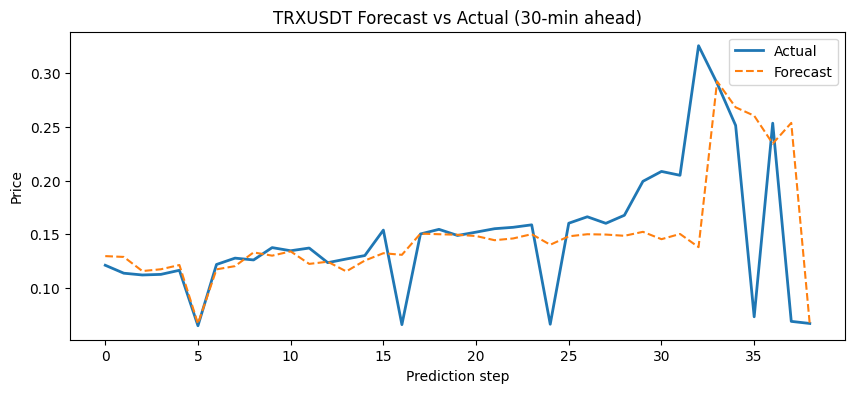


Training: XRPUSDT
XRPUSDT RMSE: 0.490586
XRPUSDT Mean Actual Price: 0.774849
XRPUSDT NRMSE (% of mean price): 0.6331%


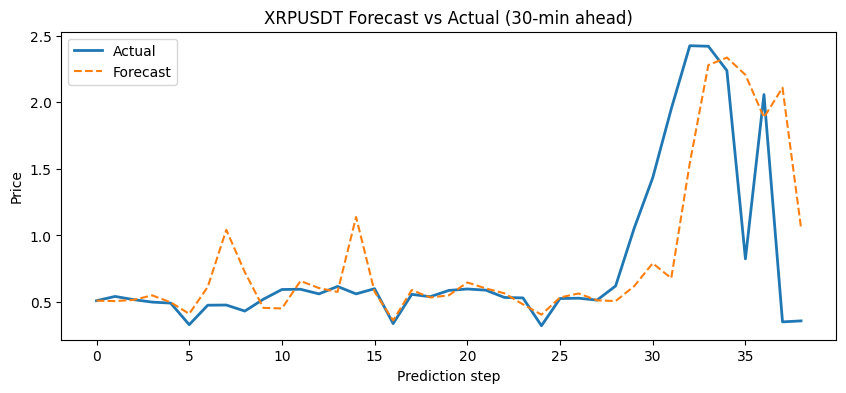

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4672,0.430223,-0.079147
1,ADAUSDT,0.4623,0.436188,-0.056482
2,ADAUSDT,0.4470,0.501902,0.122824
3,ADAUSDT,0.4492,0.455375,0.013747
4,ADAUSDT,0.4378,0.444392,0.015058
...,...,...,...,...
307,XRPUSDT,2.2390,2.336861,0.043707
308,XRPUSDT,0.8240,2.206910,1.678289
309,XRPUSDT,2.0587,1.886836,-0.083482
310,XRPUSDT,0.3505,2.110292,5.020804



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Mean,NRMSE_Percent
BNBUSDT,91.077701,545.711282,0.166897,0.166897
ETHUSDT,543.011128,2851.582564,0.190424,0.190424
SOLUSDT,32.606461,152.974615,0.213149,0.213149
BTCUSDT,14863.288045,64286.045128,0.231206,0.231206
BCHUSDT,88.484263,367.982051,0.240458,0.240458
ADAUSDT,0.160889,0.528646,0.304341,0.304341
TRXUSDT,0.056930,0.147867,0.385008,0.385008
XRPUSDT,0.490586,0.774849,0.633138,0.633138


In [2]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

#lags to be 2xhorizon, so 2x30 because 30 minutes
data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

#table of lags
def create_lags(df, n_lags):
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["close"].shift(i)
    return df

#total files
files = os.listdir(data_folder)

#looping through coins
for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index","close","time"]

    # ensure numeric just in case
    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    # ensuring chronological order, just in case
    df = df.sort_values("time")

    df = df[["close"]]


    # Handle tiny-price coins

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected â†’ using log price")
        df["close"] = np.log(df["close"])

    df["target"] = df["close"].shift(-HORIZON)

    df = create_lags(df, N_LAGS)

    df = df.dropna().reset_index(drop=True)

    #train test split
    X = df.drop(columns=["target"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Model
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    #predict
    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    preds = np.array(preds)
    actual = np.array(actual)

    # raw RMSE
    rmse = np.sqrt(mean_squared_error(actual, preds))

    # NEW: normalize by mean actual price
    mean_actual_price = actual.mean()
    nrmse_mean = rmse / mean_actual_price
    nrmse_pct = nrmse_mean

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Mean": nrmse_mean,
        "NRMSE_Percent": nrmse_pct
    }

    print(f"{coin} RMSE: {rmse:.6f}")
    print(f"{coin} Mean Actual Price: {mean_actual_price:.6f}")
    print(f"{coin} NRMSE (% of mean price): {nrmse_pct:.4f}%")

    # Ssave table
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - actual) / actual
    })

    all_tables.append(table)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual (30-min ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

#final table
final_table = pd.concat(all_tables, ignore_index=True)

display(final_table)

# save predictions
final_table.to_csv("12 XGB results/xgboost_forecasts.csv", index=False)

#rmse summary
rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("NRMSE_Percent")

rmse_table.to_csv("12 XGB results/RMSE1_normalized.csv", index=True)

print("\nRMSE Summary")
display(rmse_table)

In [3]:
np.save("12 XGB results/xgboost_forecasts.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
# np.save("12 XGB results/RMSE1_normalized.npy", rmse_table.values)
print("Saved .npy files for Model 1 (Base)")

Saved .npy files for Model 1 (Base)


## Model 2 — XGBoost Features

c:\Users\ameli\Documents\all ur code projects\optimising-dynamic-crypto-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files detected: 8
['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']

Training: ADAUSDT
ADAUSDT RMSE: 0.23214559937900137


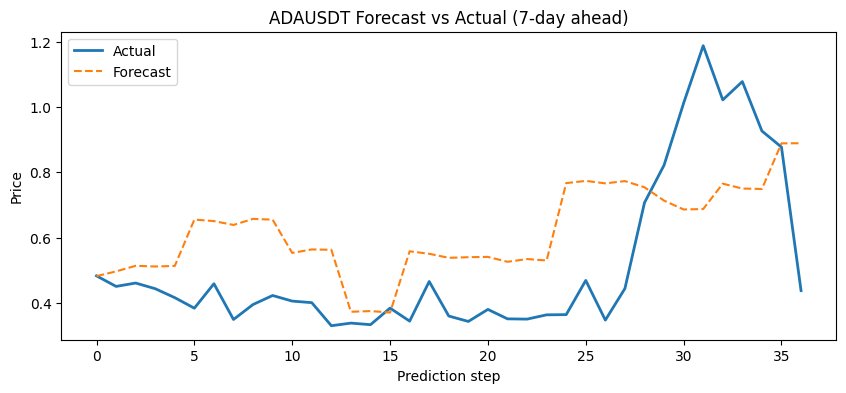


Training: BCHUSDT
BCHUSDT RMSE: 197.0139674373993


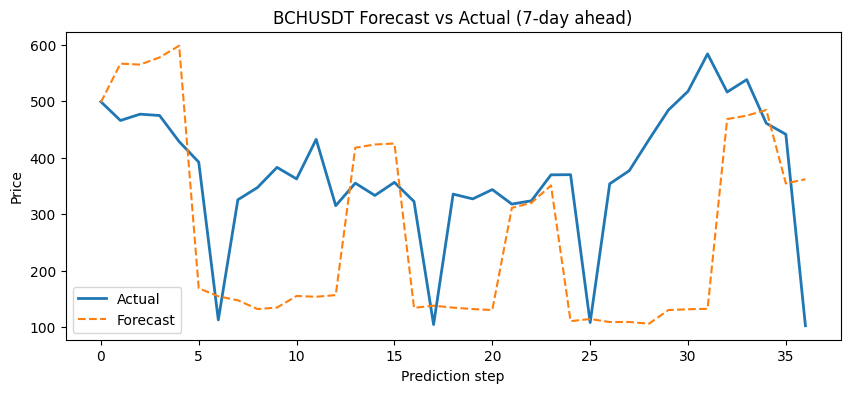


Training: BNBUSDT
BNBUSDT RMSE: 285.7360054027656


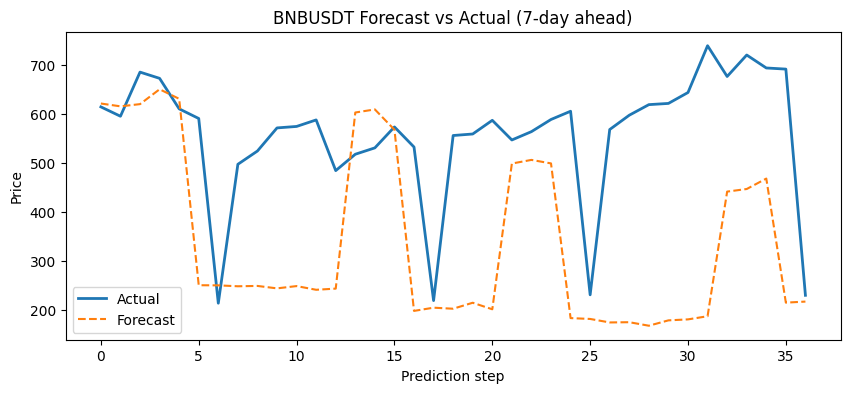


Training: BTCUSDT
BTCUSDT RMSE: 36116.49196802857


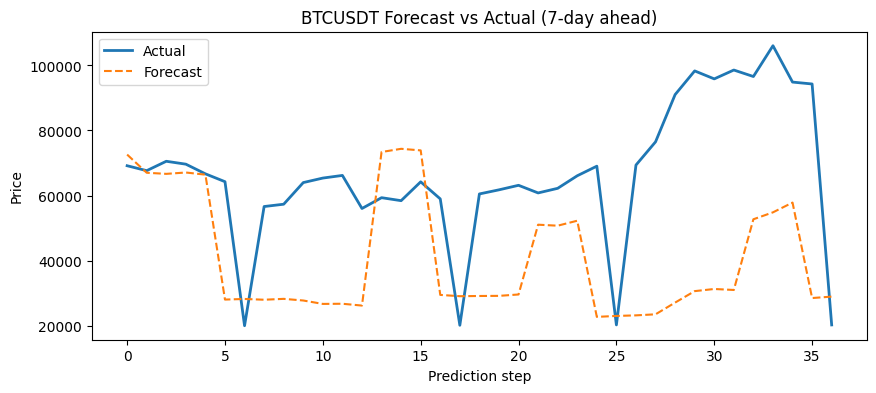


Training: ETHUSDT
ETHUSDT RMSE: 1269.4626584004602


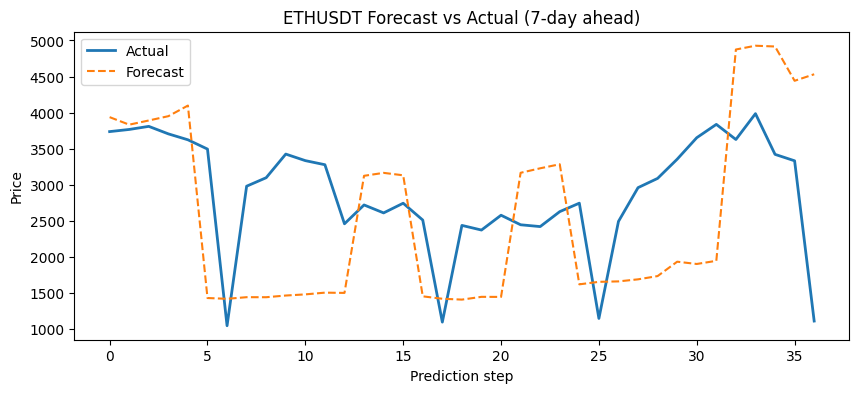


Training: SOLUSDT
SOLUSDT RMSE: 112.78144935719983


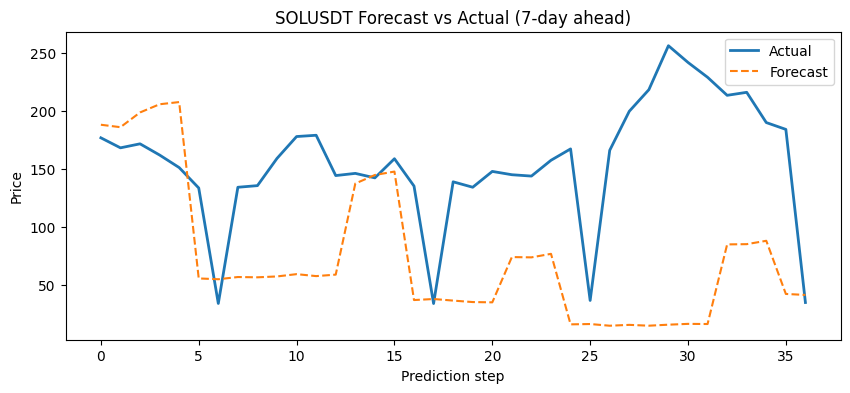


Training: TRXUSDT
TRXUSDT RMSE: 0.09454966702386039


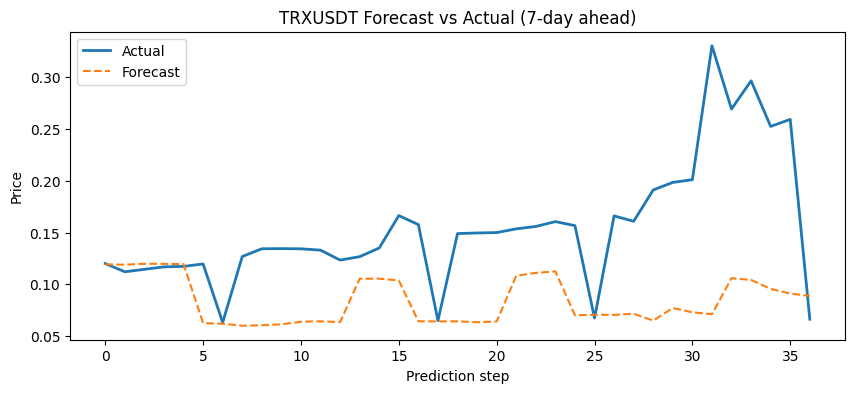


Training: XRPUSDT
XRPUSDT RMSE: 0.600473540026497


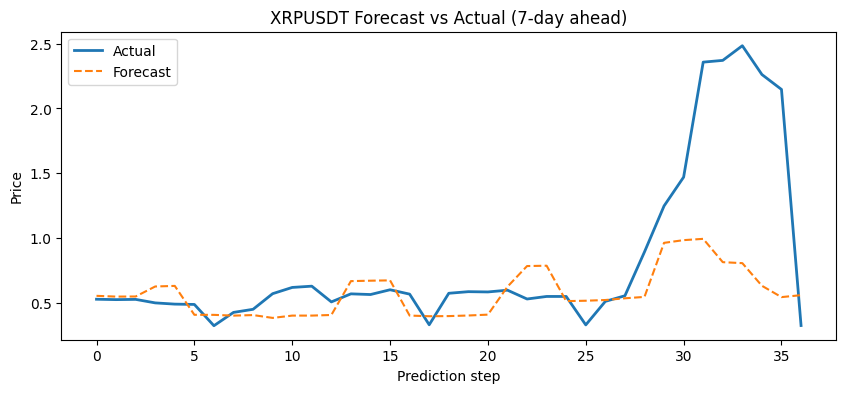

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4835,0.482676,-0.001705
1,ADAUSDT,0.4512,0.497078,0.029401
2,ADAUSDT,0.4615,0.514253,0.033968
3,ADAUSDT,0.4442,0.512066,-0.004262
4,ADAUSDT,0.4168,0.513821,0.003421
...,...,...,...,...
32,XRPUSDT,2.3709,0.812999,-0.200086
33,XRPUSDT,2.4841,0.805393,-0.009400
34,XRPUSDT,2.2617,0.630641,-0.244593
35,XRPUSDT,2.1466,0.543172,-0.149311



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Percent
TRXUSDT,0.094550,0.155034,0.609866
ADAUSDT,0.232146,0.516959,0.449060
XRPUSDT,0.600474,0.813641,0.738008
SOLUSDT,112.781449,155.928108,0.723291
BCHUSDT,197.013967,372.651351,0.528682
BNBUSDT,285.736005,558.116486,0.511965
ETHUSDT,1269.462658,2895.692973,0.438397
BTCUSDT,36116.491968,66489.435946,0.543191


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"

HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

# Lag funct
def create_lags(df, col, n_lags):

    for i in range(1, n_lags + 1):
        df[f"{col}_lag_{i}"] = df[col].shift(i)

    return df

files = os.listdir(data_folder)

print("Files detected:", len(files))
print(files[:10])

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")

    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)

    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")
    # Returns
    df["return"] = np.log(df["close"] / df["close"].shift(1))


    # rolling vol
    df["vol_30"] = df["return"].rolling(30).std()
    df["vol_60"] = df["return"].rolling(60).std()

    df["target"] = df["return"].shift(-HORIZON)

    df = create_lags(df, "return", N_LAGS)
    df = create_lags(df, "vol_30", 10)
    df = create_lags(df, "vol_60", 10)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target","close","time"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]
    # Model
    model = xgb.XGBRegressor(

        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42

    )

    model.fit(X_train, y_train)

    preds_return = []
    actual_return = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        preds_return.append(pred)

        actual_return.append(y_test.iloc[i])


    actual_price = df["close"].iloc[split::7].values[:len(preds_return)]

    start_price = df["close"].iloc[split]

    preds_price = []

    price = start_price

    for r in preds_return:

        price = price * np.exp(r)

        preds_price.append(price)


    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    mean_actual_price = np.mean(actual_price)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"{coin} RMSE:", rmse)



    table = pd.DataFrame({

        "coin": coin,
        "actual": actual_price,
        "forecast": preds_price,
        "returns_predicted": preds_return

    })

    all_tables.append(table)



    plt.figure(figsize=(10,4))

    plt.plot(actual_price, label="Actual", linewidth=2)
    plt.plot(preds_price, label="Forecast", linestyle="--")

    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")

    plt.legend()

    plt.show()



final_table = pd.concat(all_tables)

display(final_table)

final_table.to_csv("12 XGB results/xgb_feature_forecasts.csv", index=False)


rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\nRMSE Summary")
display(rmse_table)
rmse_table.to_csv("12 XGB results/xgb_feature_rmses.csv", index=True)

In [5]:
np.save("12 XGB results/xgb_feature_forecasts.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
# np.save("12 XGB results/xgb_feature_rmses.npy", rmse_table.values)
print("Saved .npy files for Model 2 (Features)")

Saved .npy files for Model 2 (Features)


## Model 3 — XGBoost Bayesian Optimised (BO)


Training: ADAUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:08:58,173] A new study created in memory with name: no-name-38b6ae7c-609c-4101-89e1-b3b4448907eb


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.333419:   3%|▎         | 1/30 [00:00<00:05,  5.31it/s]

[I 2026-04-19 17:08:58,358] Trial 0 finished with value: 0.3334188239923498 and parameters: {'n_estimators': 387, 'max_depth': 5, 'learning_rate': 0.14889347688303112, 'subsample': 0.5255109862453944, 'colsample_bytree': 0.806891822318863, 'gamma': 2.6222001553111642, 'reg_alpha': 3.8177661635962084, 'reg_lambda': 0.9323754199233519}. Best is trial 0 with value: 0.3334188239923498.


...

[I 2026-04-19 17:09:02,836] Trial 27 finished with value: 0.2683250121794745 and parameters: {'n_estimators': 239, 'max_depth': 6, 'learning_rate': 0.0872364754236958, 'subsample': 0.9101231910269696, 'colsample_bytree': 0.7736337361410011, 'gamma': 0.9962012926232229, 'reg_alpha': 1.234062839030293, 'reg_lambda': 3.178535782309143}. Best is trial 23 with value: 0.20626197894718315.


Best trial: 23. Best value: 0.206262:  97%|█████████▋| 29/30 [00:04<00:00,  5.14it/s]

[I 2026-04-19 17:09:03,041] Trial 28 finished with value: 0.2901157780356335 and parameters: {'n_estimators': 308, 'max_depth': 4, 'learning_rate': 0.054608047785562774, 'subsample': 0.9629941676620909, 'colsample_bytree': 0.9996134752594127, 'gamma': 1.3250400819581731, 'reg_alpha': 2.650542316345131, 'reg_lambda': 3.719250653979228}. Best is trial 23 with value: 0.20626197894718315.


Best trial: 23. Best value: 0.206262: 100%|██████████| 30/30 [00:05<00:00,  5.87it/s]


[I 2026-04-19 17:09:03,278] Trial 29 finished with value: 0.2500966368091974 and parameters: {'n_estimators': 377, 'max_depth': 5, 'learning_rate': 0.14710584393958767, 'subsample': 0.8706582478326254, 'colsample_bytree': 0.8563938923132195, 'gamma': 0.6249316325000899, 'reg_alpha': 1.704277701522477, 'reg_lambda': 1.1849372107819194}. Best is trial 23 with value: 0.20626197894718315.
Best params: {'n_estimators': 331, 'max_depth': 3, 'learning_rate': 0.08630967295531095, 'subsample': 0.8397527907550993, 'colsample_bytree': 0.9499016990377258, 'gamma': 0.023687773594510783, 'reg_alpha': 1.5335610516571316, 'reg_lambda': 3.8183322642508637}

Top 10 Most Important Features:
   feature  importance
     close    0.519407
     lag_1    0.258783
     lag_4    0.038827
     lag_2    0.028613
     lag_9    0.026339
     lag_5    0.020254
volatility    0.017325
    lag_14    0.015729
    lag_13    0.014064
     lag_3    0.013855

ADAUSDT RMSE: 0.081963


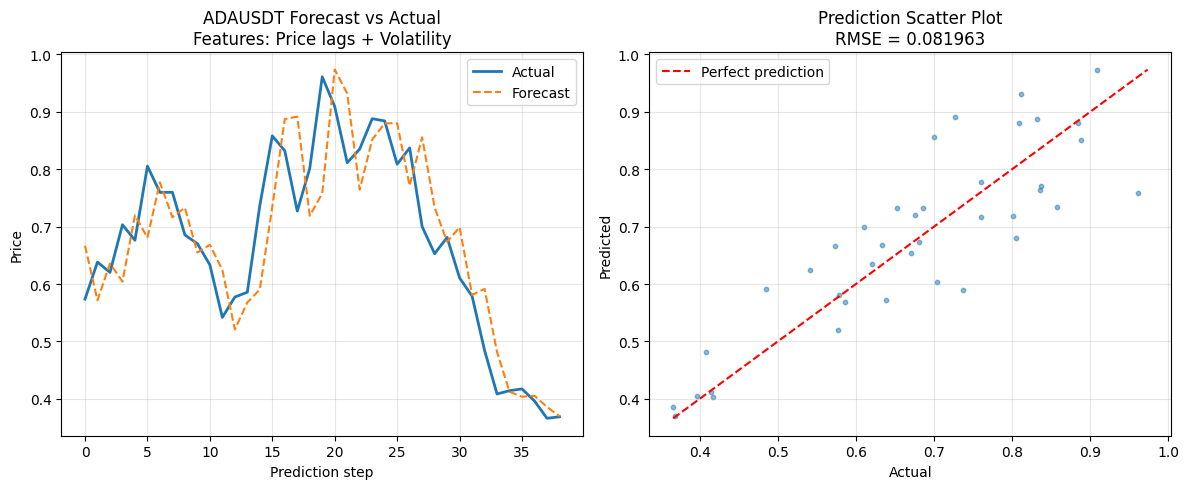

C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:09:04,341] A new study created in memory with name: no-name-fe7bc611-79e6-4f62-8a2b-df3b0aa8b2d6



Training: BCHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 65.7855:   3%|▎         | 1/30 [00:00<00:23,  1.23it/s]

[I 2026-04-19 17:09:05,150] Trial 0 finished with value: 65.78547482242881 and parameters: {'n_estimators': 452, 'max_depth': 5, 'learning_rate': 0.06239986965219221, 'subsample': 0.9700853826343083, 'colsample_bytree': 0.881627040881934, 'gamma': 1.2545594101219015, 'reg_alpha': 0.9072023308512411, 'reg_lambda': 1.9634373224920332}. Best is trial 0 with value: 65.78547482242881.


Best trial: 1. Best value: 63.0706:   7%|▋         | 2/30 [00:01<00:16,  1.73it/s]

...

[I 2026-04-19 17:09:18,235] Trial 27 finished with value: 59.692359513181586 and parameters: {'n_estimators': 304, 'max_depth': 3, 'learning_rate': 0.06090354589860225, 'subsample': 0.6643623829135993, 'colsample_bytree': 0.8485343200422856, 'gamma': 0.3638230244172487, 'reg_alpha': 4.96702686214486, 'reg_lambda': 2.845113559823675}. Best is trial 4 with value: 52.52576537199146.


Best trial: 4. Best value: 52.5258:  97%|█████████▋| 29/30 [00:14<00:00,  1.87it/s]

[I 2026-04-19 17:09:19,043] Trial 28 finished with value: 56.76474560349965 and parameters: {'n_estimators': 436, 'max_depth': 5, 'learning_rate': 0.010458164765147757, 'subsample': 0.5473629790214913, 'colsample_bytree': 0.9988703428170977, 'gamma': 3.995402903109751, 'reg_alpha': 3.496672414127514, 'reg_lambda': 3.432282806934674}. Best is trial 4 with value: 52.52576537199146.


Best trial: 4. Best value: 52.5258: 100%|██████████| 30/30 [00:15<00:00,  1.93it/s]


[I 2026-04-19 17:09:19,896] Trial 29 finished with value: 60.6258879074217 and parameters: {'n_estimators': 464, 'max_depth': 5, 'learning_rate': 0.062128678010770585, 'subsample': 0.5934317377892749, 'colsample_bytree': 0.8812851102391054, 'gamma': 4.691202458720844, 'reg_alpha': 1.1611964612081838, 'reg_lambda': 1.8440063132056534}. Best is trial 4 with value: 52.52576537199146.
Best params: {'n_estimators': 264, 'max_depth': 3, 'learning_rate': 0.012217620944979465, 'subsample': 0.5327098692718304, 'colsample_bytree': 0.9981098967264261, 'gamma': 4.687313011051978, 'reg_alpha': 3.884124659772572, 'reg_lambda': 3.9853457798323704}

Top 10 Most Important Features:
feature  importance
  close    0.286570
  lag_1    0.280227
  lag_2    0.139943
  lag_3    0.058115
  lag_5    0.051677
  lag_4    0.030258
  lag_8    0.019691
 lag_12    0.018994
 lag_13    0.017110
  lag_7    0.016563

BCHUSDT RMSE: 74.564249


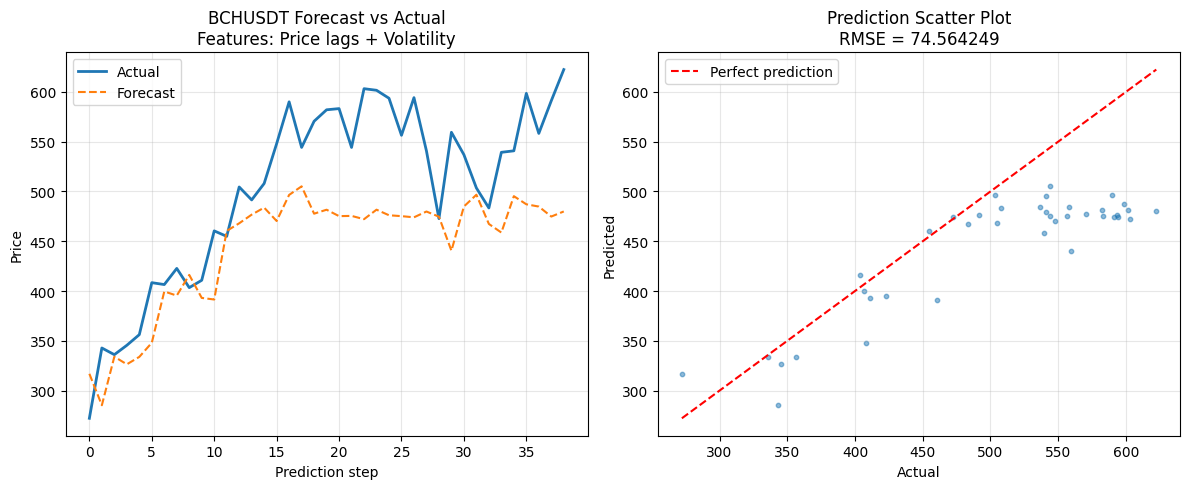

C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:09:21,031] A new study created in memory with name: no-name-802044e1-a907-48af-8317-fe8909635454



Training: BNBUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 67.5295:   3%|▎         | 1/30 [00:00<00:08,  3.36it/s]

[I 2026-04-19 17:09:21,325] Trial 0 finished with value: 67.52945218210577 and parameters: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.10450865456083154, 'subsample': 0.9850342077647257, 'colsample_bytree': 0.9872757076852341, 'gamma': 4.682388556298191, 'reg_alpha': 0.5383909271239073, 'reg_lambda': 0.47099705050596186}. Best is trial 0 with value: 67.52945218210577.


Best trial: 0. Best value: 67.5295:   7%|▋         | 2/30 [00:01<00:17,  1.61it/s]

...

[I 2026-04-19 17:09:31,168] Trial 27 finished with value: 68.51329642941776 and parameters: {'n_estimators': 244, 'max_depth': 4, 'learning_rate': 0.08345490114440925, 'subsample': 0.9218448965705861, 'colsample_bytree': 0.673214258644184, 'gamma': 3.284907253199891, 'reg_alpha': 0.725428062924569, 'reg_lambda': 4.401819342903555}. Best is trial 13 with value: 66.00551499762751.


Best trial: 13. Best value: 66.0055:  97%|█████████▋| 29/30 [00:10<00:00,  3.52it/s]

[I 2026-04-19 17:09:31,493] Trial 28 finished with value: 68.17739156896104 and parameters: {'n_estimators': 320, 'max_depth': 3, 'learning_rate': 0.06489042767258235, 'subsample': 0.7690576390936142, 'colsample_bytree': 0.9001156083191293, 'gamma': 1.5411964687861928, 'reg_alpha': 3.7673933420083583, 'reg_lambda': 3.7564542855829415}. Best is trial 13 with value: 66.00551499762751.


Best trial: 13. Best value: 66.0055: 100%|██████████| 30/30 [00:10<00:00,  2.77it/s]


[I 2026-04-19 17:09:31,856] Trial 29 finished with value: 71.3185757001211 and parameters: {'n_estimators': 149, 'max_depth': 6, 'learning_rate': 0.1147375847052527, 'subsample': 0.9563600350640307, 'colsample_bytree': 0.9818635841524841, 'gamma': 3.8558824242858716, 'reg_alpha': 0.49391702792323944, 'reg_lambda': 3.0076159118386574}. Best is trial 13 with value: 66.00551499762751.
Best params: {'n_estimators': 104, 'max_depth': 3, 'learning_rate': 0.11279998894903626, 'subsample': 0.9975096629530468, 'colsample_bytree': 0.8408213326917632, 'gamma': 3.319596543066266, 'reg_alpha': 1.1426273989697289, 'reg_lambda': 3.49421123365984}

Top 10 Most Important Features:
feature  importance
  lag_1    0.448327
  close    0.409361
  lag_2    0.077130
  lag_5    0.009988
  lag_6    0.009964
 lag_13    0.009106
  lag_4    0.006892
 lag_14    0.004369
  lag_3    0.003835
  lag_7    0.003651

BNBUSDT RMSE: 224.114255


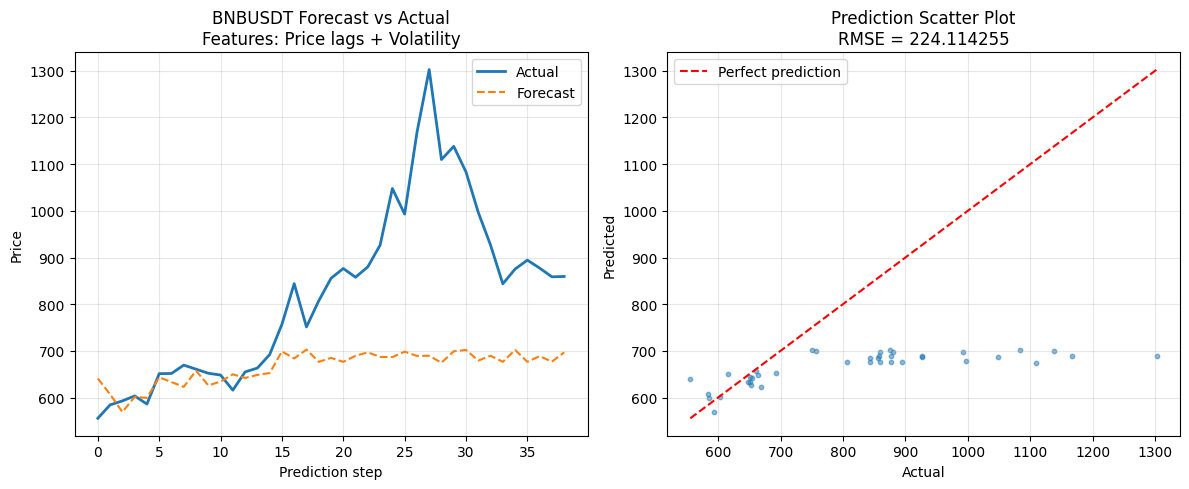

C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:09:32,751] A new study created in memory with name: no-name-7f630931-afbd-4bbc-bbc3-7d98ae9befb9



Training: BTCUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 24205.5:   3%|▎         | 1/30 [00:00<00:23,  1.22it/s]

[I 2026-04-19 17:09:33,565] Trial 0 finished with value: 24205.50415730849 and parameters: {'n_estimators': 421, 'max_depth': 6, 'learning_rate': 0.07789710196486058, 'subsample': 0.9537460520923795, 'colsample_bytree': 0.8694618314447953, 'gamma': 2.9838451590235744, 'reg_alpha': 0.6873675635742532, 'reg_lambda': 3.9528125237784235}. Best is trial 0 with value: 24205.50415730849.


Best trial: 1. Best value: 23668.3:   7%|▋         | 2/30 [00:01<00:17,  1.62it/s]

...

[I 2026-04-19 17:09:46,202] Trial 27 finished with value: 23499.713947706725 and parameters: {'n_estimators': 343, 'max_depth': 3, 'learning_rate': 0.1172190292456322, 'subsample': 0.758872756278297, 'colsample_bytree': 0.9931331178583243, 'gamma': 4.062267795688584, 'reg_alpha': 4.676436202179632, 'reg_lambda': 2.9448071372720115}. Best is trial 26 with value: 21695.356928150046.


Best trial: 26. Best value: 21695.4:  97%|█████████▋| 29/30 [00:13<00:00,  3.98it/s]

[I 2026-04-19 17:09:46,463] Trial 28 finished with value: 24115.48848406043 and parameters: {'n_estimators': 146, 'max_depth': 5, 'learning_rate': 0.07935881605006548, 'subsample': 0.711239173482173, 'colsample_bytree': 0.8767461252794873, 'gamma': 4.383481257689194, 'reg_alpha': 4.017248915606916, 'reg_lambda': 2.7462723468488353}. Best is trial 26 with value: 21695.356928150046.


Best trial: 26. Best value: 21695.4: 100%|██████████| 30/30 [00:14<00:00,  2.05it/s]


[I 2026-04-19 17:09:47,347] Trial 29 finished with value: 24578.235217880927 and parameters: {'n_estimators': 401, 'max_depth': 6, 'learning_rate': 0.0698292721407576, 'subsample': 0.7898850391686774, 'colsample_bytree': 0.9536121056522602, 'gamma': 3.1815239847264136, 'reg_alpha': 3.5379964889440347, 'reg_lambda': 3.657615279187718}. Best is trial 26 with value: 21695.356928150046.
Best params: {'n_estimators': 141, 'max_depth': 3, 'learning_rate': 0.07253054474867428, 'subsample': 0.7935129113613204, 'colsample_bytree': 0.9309208587644954, 'gamma': 4.2683054790481165, 'reg_alpha': 4.189623771748561, 'reg_lambda': 2.8282552243175036}

Top 10 Most Important Features:
feature  importance
  lag_4    0.293823
  lag_5    0.189637
  lag_1    0.162443
  close    0.137180
  lag_9    0.074002
  lag_7    0.058578
 lag_10    0.040958
  lag_8    0.010161
  lag_2    0.008300
  lag_3    0.008138

BTCUSDT RMSE: 13644.041864


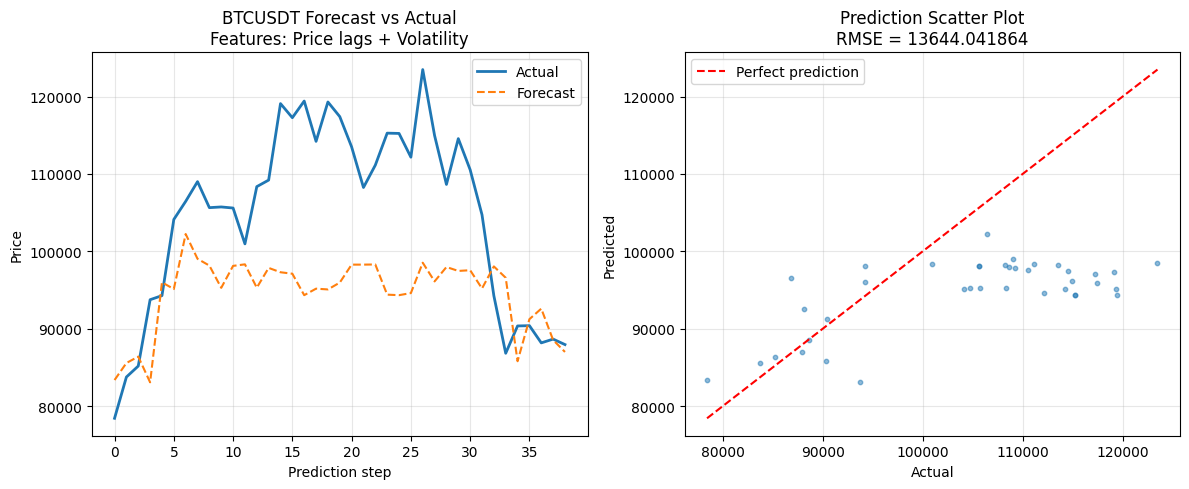

C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:09:48,274] A new study created in memory with name: no-name-441aacfd-563a-4430-bc9b-8c1ed5d478f8



Training: ETHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 301.542:   3%|▎         | 1/30 [00:01<00:51,  1.78s/it]

[I 2026-04-19 17:09:50,054] Trial 0 finished with value: 301.54173948122923 and parameters: {'n_estimators': 474, 'max_depth': 7, 'learning_rate': 0.014930736229478127, 'subsample': 0.8705294183511973, 'colsample_bytree': 0.7831101499120462, 'gamma': 0.9986193168182667, 'reg_alpha': 3.0270169625006664, 'reg_lambda': 4.728948760034427}. Best is trial 0 with value: 301.54173948122923.


Best trial: 0. Best value: 301.542:   7%|▋         | 2/30 [00:02<00:30,  1.10s/it]

...

[I 2026-04-19 17:10:03,238] Trial 27 finished with value: 292.58529069413794 and parameters: {'n_estimators': 139, 'max_depth': 3, 'learning_rate': 0.04690000802556819, 'subsample': 0.5995887902812997, 'colsample_bytree': 0.8561926238786607, 'gamma': 3.406863135353998, 'reg_alpha': 3.152101656478911, 'reg_lambda': 0.01010830553112485}. Best is trial 22 with value: 284.3960267182572.


Best trial: 22. Best value: 284.396:  97%|█████████▋| 29/30 [00:15<00:00,  1.92it/s]

[I 2026-04-19 17:10:04,223] Trial 28 finished with value: 324.18777926553213 and parameters: {'n_estimators': 236, 'max_depth': 9, 'learning_rate': 0.010363106377686823, 'subsample': 0.7289649216250054, 'colsample_bytree': 0.9181916598244186, 'gamma': 2.8799236198794214, 'reg_alpha': 3.761647361749469, 'reg_lambda': 2.4116395289390367}. Best is trial 22 with value: 284.3960267182572.


Best trial: 22. Best value: 284.396: 100%|██████████| 30/30 [00:16<00:00,  1.77it/s]


[I 2026-04-19 17:10:05,201] Trial 29 finished with value: 309.3352190869972 and parameters: {'n_estimators': 446, 'max_depth': 7, 'learning_rate': 0.09949835324888358, 'subsample': 0.6343003216587093, 'colsample_bytree': 0.7423567289967387, 'gamma': 2.2435664389981542, 'reg_alpha': 2.7869326426678724, 'reg_lambda': 1.8405165497713576}. Best is trial 22 with value: 284.3960267182572.
Best params: {'n_estimators': 233, 'max_depth': 3, 'learning_rate': 0.030734363768660553, 'subsample': 0.975638057485974, 'colsample_bytree': 0.8554659348645279, 'gamma': 3.39789465842104, 'reg_alpha': 4.486288315596774, 'reg_lambda': 1.8881965777782765}

Top 10 Most Important Features:
feature  importance
  lag_2    0.340509
  close    0.291240
  lag_1    0.246131
  lag_4    0.031577
  lag_5    0.011541
 lag_12    0.009666
  lag_7    0.009244
 lag_13    0.008411
  lag_6    0.008383
  lag_8    0.008315

ETHUSDT RMSE: 539.243892


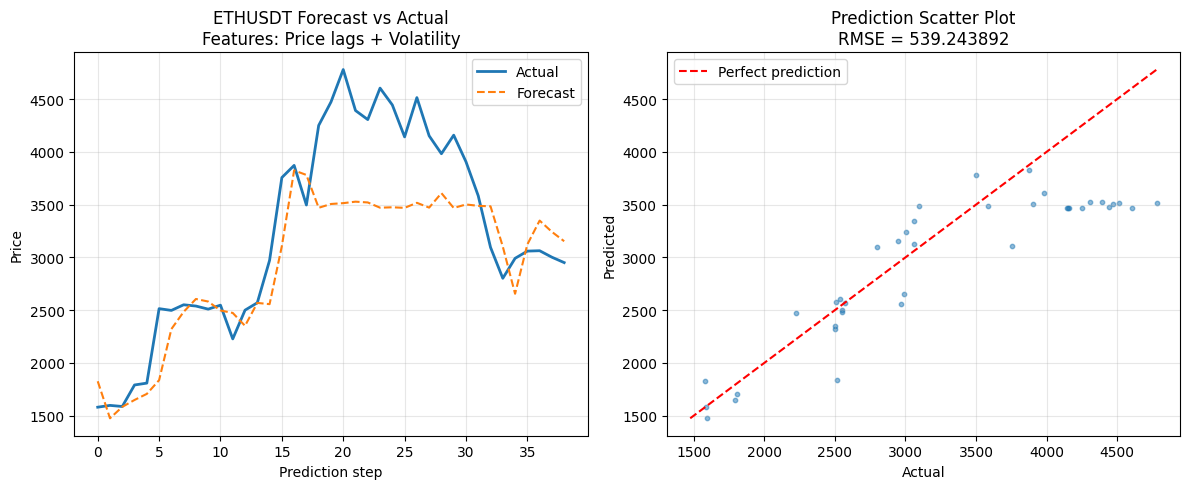

C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:10:06,302] A new study created in memory with name: no-name-ba1131aa-62c6-49e8-becf-f16f16002c3e



Training: SOLUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 41.9935:   3%|▎         | 1/30 [00:00<00:09,  2.97it/s]

[I 2026-04-19 17:10:06,634] Trial 0 finished with value: 41.99349278479666 and parameters: {'n_estimators': 388, 'max_depth': 3, 'learning_rate': 0.14182278875006885, 'subsample': 0.5580929968582341, 'colsample_bytree': 0.9420786719834204, 'gamma': 3.6451178128384196, 'reg_alpha': 1.0206784485532316, 'reg_lambda': 3.1259554017325417}. Best is trial 0 with value: 41.99349278479666.


Best trial: 1. Best value: 36.0103:   7%|▋         | 2/30 [00:00<00:09,  2.99it/s]

...

[I 2026-04-19 17:10:20,537] Trial 27 finished with value: 35.00627801499748 and parameters: {'n_estimators': 327, 'max_depth': 3, 'learning_rate': 0.19590520064170086, 'subsample': 0.9575297902571788, 'colsample_bytree': 0.62653694628609, 'gamma': 1.385734197431922, 'reg_alpha': 0.8667549244576465, 'reg_lambda': 2.054211594265775}. Best is trial 12 with value: 33.266919456059256.


Best trial: 12. Best value: 33.2669:  97%|█████████▋| 29/30 [00:14<00:00,  2.75it/s]

[I 2026-04-19 17:10:21,017] Trial 28 finished with value: 35.48904176914128 and parameters: {'n_estimators': 377, 'max_depth': 3, 'learning_rate': 0.15687220731671658, 'subsample': 0.5024538082997712, 'colsample_bytree': 0.6813143668612055, 'gamma': 0.5439320080413498, 'reg_alpha': 0.490379711399349, 'reg_lambda': 0.42204403506536076}. Best is trial 12 with value: 33.266919456059256.


Best trial: 12. Best value: 33.2669: 100%|██████████| 30/30 [00:15<00:00,  1.99it/s]


[I 2026-04-19 17:10:21,358] Trial 29 finished with value: 36.98161543950338 and parameters: {'n_estimators': 278, 'max_depth': 3, 'learning_rate': 0.1424201220412277, 'subsample': 0.8707569032816649, 'colsample_bytree': 0.7846873626347106, 'gamma': 1.9001651889727955, 'reg_alpha': 1.0080203150994733, 'reg_lambda': 1.2272415230276759}. Best is trial 12 with value: 33.266919456059256.
Best params: {'n_estimators': 199, 'max_depth': 4, 'learning_rate': 0.19150755365476907, 'subsample': 0.9253040567590695, 'colsample_bytree': 0.856121836722926, 'gamma': 2.988846152042518, 'reg_alpha': 0.048638158376443835, 'reg_lambda': 0.1023222503232959}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.686768
     close    0.233362
     lag_2    0.029202
     lag_4    0.008477
    lag_14    0.004863
volatility    0.004520
    lag_13    0.004377
     lag_7    0.004325
     lag_6    0.004299
    lag_12    0.003230

SOLUSDT RMSE: 20.085698


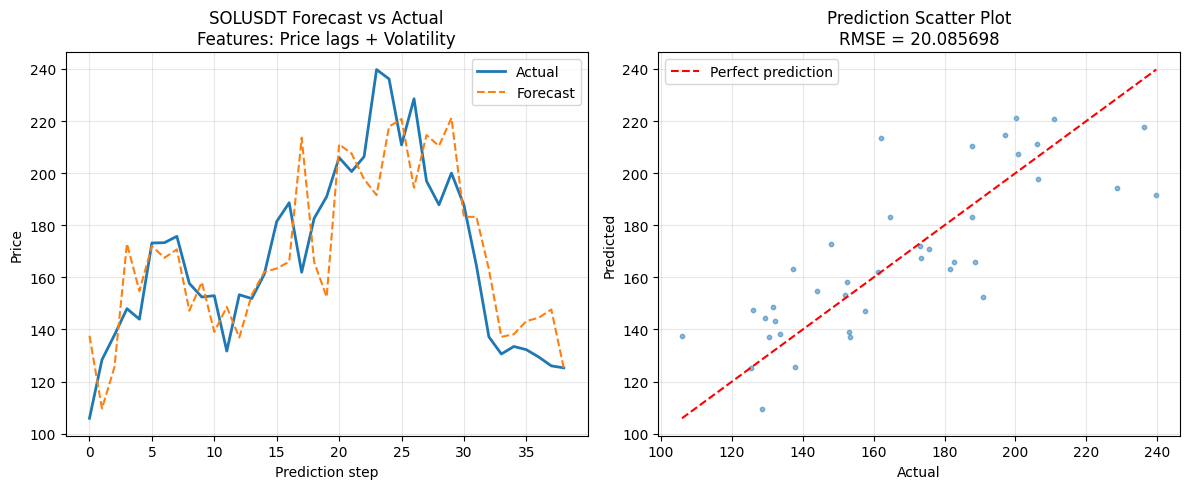

C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:10:22,471] A new study created in memory with name: no-name-b32779eb-19b5-40ed-8b71-2bcb6a923adb



Training: TRXUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.12603:   3%|▎         | 1/30 [00:00<00:05,  5.77it/s]

[I 2026-04-19 17:10:22,642] Trial 0 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 280, 'max_depth': 5, 'learning_rate': 0.15315351649569747, 'subsample': 0.8691727108901985, 'colsample_bytree': 0.5174168240605088, 'gamma': 0.6940442215528719, 'reg_alpha': 2.091562539570424, 'reg_lambda': 3.1558163372309394}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-19 17:10:22,727] Trial 1 finished with value: 0.1260534403278305 and parameters: {'n_estimators': 105, 'max_depth': 10, 'learning_rate': 0.0874615017093558, 'subsample': 0.6432767343440848, 'colsample_bytree': 0.5759926835268602, 'gamma': 1.6130066531808636, 'reg_alpha': 0.7570282824048835, 'reg_lambda': 0.40388982253552863}. Best is trial 0 with value: 0.12602966170678476.


Best trial: 0. Best value: 0.12603:  10%|█         | 3/30 [00:00<00:03,  7.07it/s]

...

[I 2026-04-19 17:10:27,933] Trial 25 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 266, 'max_depth': 5, 'learning_rate': 0.028877937725537817, 'subsample': 0.942976317695687, 'colsample_bytree': 0.6828237708566807, 'gamma': 0.5198782260874778, 'reg_alpha': 4.094957723925052, 'reg_lambda': 2.017684492928531}. Best is trial 13 with value: 0.11069407788634517.
[I 2026-04-19 17:10:28,127] Trial 26 finished with value: 0.11605573854250993 and parameters: {'n_estimators': 338, 'max_depth': 4, 'learning_rate': 0.032682709873261384, 'subsample': 0.8459439119834863, 'colsample_bytree': 0.5456254626658498, 'gamma': 0.013073777698507445, 'reg_alpha': 3.4685405989822047, 'reg_lambda': 1.134331992245711}. Best is trial 13 with value: 0.11069407788634517.


Best trial: 13. Best value: 0.110694:  97%|█████████▋| 29/30 [00:06<00:00,  5.01it/s]

[I 2026-04-19 17:10:28,350] Trial 27 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 411, 'max_depth': 3, 'learning_rate': 0.10775730074858106, 'subsample': 0.7767587398925524, 'colsample_bytree': 0.5454009507137988, 'gamma': 1.1612201401103583, 'reg_alpha': 2.3776909451650328, 'reg_lambda': 0.6864486953330006}. Best is trial 13 with value: 0.11069407788634517.
[I 2026-04-19 17:10:28,488] Trial 28 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.06176205511419143, 'subsample': 0.8424799714103418, 'colsample_bytree': 0.595595953013397, 'gamma': 4.306187970163681, 'reg_alpha': 3.297146944198869, 'reg_lambda': 1.1883612909810022}. Best is trial 13 with value: 0.11069407788634517.


Best trial: 13. Best value: 0.110694: 100%|██████████| 30/30 [00:06<00:00,  4.82it/s]


[I 2026-04-19 17:10:28,694] Trial 29 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 284, 'max_depth': 5, 'learning_rate': 0.03864302751566499, 'subsample': 0.8340527968610189, 'colsample_bytree': 0.5391143652534393, 'gamma': 0.6856880363351631, 'reg_alpha': 2.138168940288161, 'reg_lambda': 3.0168704719031796}. Best is trial 13 with value: 0.11069407788634517.
Best params: {'n_estimators': 288, 'max_depth': 6, 'learning_rate': 0.04819060510090117, 'subsample': 0.8700483341300352, 'colsample_bytree': 0.5007786269394997, 'gamma': 0.005114419430036654, 'reg_alpha': 2.7030761037336664, 'reg_lambda': 1.6781900699993284}

Top 10 Most Important Features:
feature  importance
  lag_1    0.213405
  lag_4    0.179894
  close    0.154884
  lag_2    0.131513
  lag_3    0.099065
 lag_13    0.052080
  lag_6    0.046422
  lag_9    0.038043
 lag_11    0.025332
 lag_12    0.014553

TRXUSDT RMSE: 0.084135


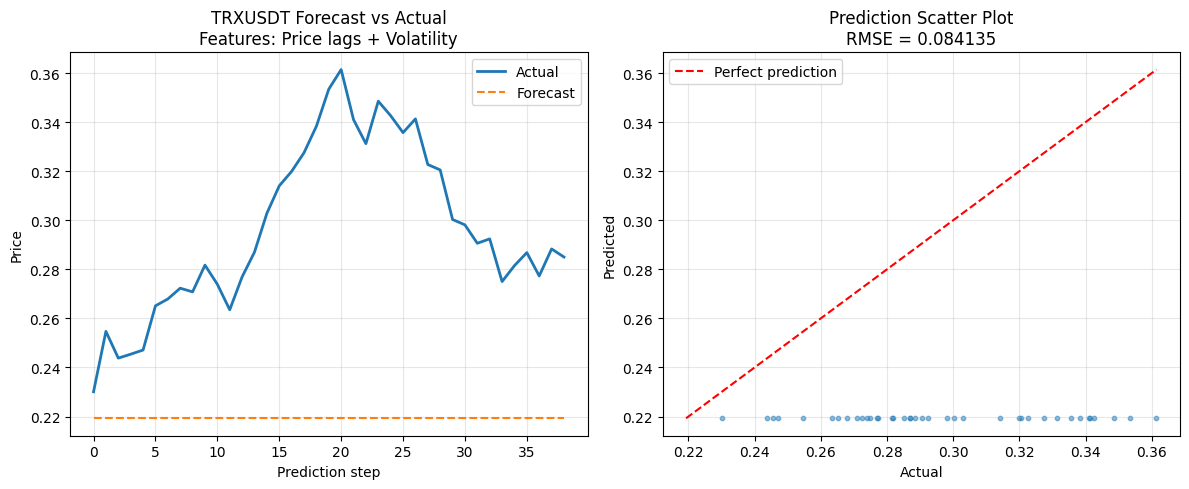

C:\Users\ameli\AppData\Local\Temp\ipykernel_22756\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 17:10:29,716] A new study created in memory with name: no-name-ce032f27-407c-4e5b-b746-6fa46fd71ccd



Training: XRPUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 1.39729:   7%|▋         | 2/30 [00:00<00:04,  5.74it/s]

[I 2026-04-19 17:10:29,967] Trial 0 finished with value: 1.397289363764823 and parameters: {'n_estimators': 454, 'max_depth': 5, 'learning_rate': 0.09629755290783187, 'subsample': 0.5036819096198218, 'colsample_bytree': 0.761479511538872, 'gamma': 2.8906941935225916, 'reg_alpha': 1.9481950290686223, 'reg_lambda': 2.7222945939901626}. Best is trial 0 with value: 1.397289363764823.
[I 2026-04-19 17:10:30,086] Trial 1 finished with value: 1.3976776274578697 and parameters: {'n_estimators': 180, 'max_depth': 7, 'learning_rate': 0.059428981625972994, 'subsample': 0.5445061068193723, 'colsample_bytree': 0.6863879363151815, 'gamma': 3.554520392880813, 'reg_alpha': 0.5107889792751913, 'reg_lambda': 2.8219328980950587}. Best is trial 0 with value: 1.397289363764823.


Best trial: 2. Best value: 1.31424:  13%|█▎        | 4/30 [00:00<00:03,  6.76it/s]

...

[I 2026-04-19 17:10:35,877] Trial 27 finished with value: 1.351281422613741 and parameters: {'n_estimators': 397, 'max_depth': 7, 'learning_rate': 0.03314641536594056, 'subsample': 0.7326454591935498, 'colsample_bytree': 0.5731710485181342, 'gamma': 0.5113635788995354, 'reg_alpha': 2.370094692116026, 'reg_lambda': 0.5566470339240994}. Best is trial 23 with value: 1.2817090225437378.


Best trial: 23. Best value: 1.28171:  97%|█████████▋| 29/30 [00:06<00:00,  3.94it/s]

[I 2026-04-19 17:10:36,144] Trial 28 finished with value: 1.352081027634513 and parameters: {'n_estimators': 359, 'max_depth': 8, 'learning_rate': 0.05443398468578671, 'subsample': 0.9614830326833101, 'colsample_bytree': 0.9406949960617265, 'gamma': 0.8623389732184739, 'reg_alpha': 0.9648559030234412, 'reg_lambda': 2.3950003244241778}. Best is trial 23 with value: 1.2817090225437378.


Best trial: 23. Best value: 1.28171: 100%|██████████| 30/30 [00:06<00:00,  4.40it/s]


[I 2026-04-19 17:10:36,529] Trial 29 finished with value: 1.3381478199710442 and parameters: {'n_estimators': 414, 'max_depth': 5, 'learning_rate': 0.10079635488255702, 'subsample': 0.8577303709977905, 'colsample_bytree': 0.7809961884046469, 'gamma': 0.35195191129464787, 'reg_alpha': 1.638500387037044, 'reg_lambda': 1.5192739182937485}. Best is trial 23 with value: 1.2817090225437378.
Best params: {'n_estimators': 331, 'max_depth': 9, 'learning_rate': 0.028612910903487457, 'subsample': 0.8969042774034155, 'colsample_bytree': 0.8027952598047461, 'gamma': 0.004435257236084389, 'reg_alpha': 0.24371168071975344, 'reg_lambda': 1.3799869072044804}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.587708
     close    0.347751
     lag_2    0.015498
     lag_3    0.013820
     lag_9    0.008204
     lag_8    0.005423
volatility    0.002607
     lag_7    0.002555
    lag_11    0.002432
log_return    0.002280

XRPUSDT RMSE: 0.399775


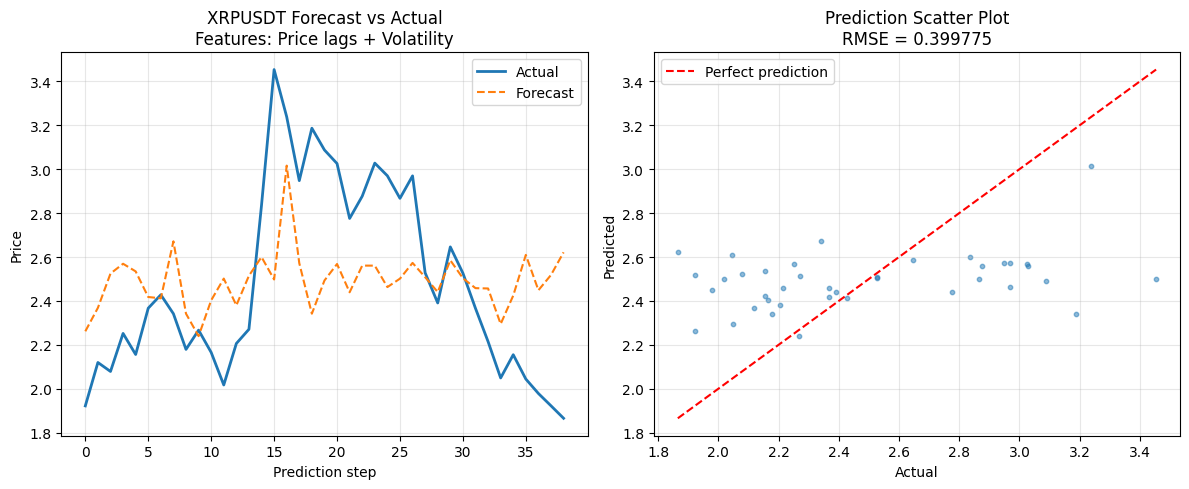


RMSE SUMMARY
                 RMSE  Mean_Actual_Price  NRMSE_Percent
ADAUSDT      0.081963           0.671769       0.122010
TRXUSDT      0.084135           0.296315       0.283937
XRPUSDT      0.399775           2.480085       0.161194
SOLUSDT     20.085698         167.505128       0.119911
BCHUSDT     74.564249         502.102564       0.148504
BNBUSDT    224.114255         820.774615       0.273052
ETHUSDT    539.243892        3219.931282       0.167471
BTCUSDT  13644.041864      104518.519744       0.130542

SUMMARY STATISTICS
Mean RMSE: 1812.826979
Median RMSE: 47.324974
Mean NRMSE (%): 0.1758%
Median NRMSE (%): 0.1548%
Best RMSE: 0.081963 (ADAUSDT)
Worst RMSE: 13644.041864 (BTCUSDT)


In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14
VOLATILITY_WINDOW = 7

results = {}
all_tables = []

def create_features(df):
    df = df.copy()

    # log return
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # volatility
    df["volatility"] = df["log_return"].rolling(window=VOLATILITY_WINDOW).std()

    # lagged prices only
    for i in range(1, N_LAGS + 1):
        df[f"lag_{i}"] = df["close"].shift(i)

    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv", "")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index", "close", "time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time")
    df = df[["close"]]

    # tiny coins
    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected â†’ using log price")
        df["close"] = np.log(df["close"])

    # add features: price lags + volatility only
    df = create_features(df)

    # target = future closing price HORIZON steps ahead
    df["target"] = df["close"].shift(-HORIZON)

    # drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # exclude target, keep everything else
    X = df.drop(columns=["target"])
    y = df["target"]

    split1 = int(len(df) * 0.6)
    split2 = int(len(df) * 0.8)

    X_train = X.iloc[:split1]
    X_val   = X.iloc[split1:split2]
    X_test  = X.iloc[split2:]

    y_train = y.iloc[:split1]
    y_val   = y.iloc[split1:split2]
    y_test  = y.iloc[split2:]

    print(f"Features used ({len(X.columns)} total):")
    price_lags = [col for col in X.columns if col.startswith("lag_")]
    vol_features = [col for col in X.columns if "vol" in col.lower()]
    other_features = [col for col in X.columns if col not in price_lags and col not in vol_features]

    print(f"  - Price lags: {len(price_lags)} features")
    print(f"  - Volatility features: {len(vol_features)} features")
    print(f"  - Other features: {len(other_features)} features")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

    # Bayesian Optimisation
    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "objective": "reg:squarederror",
            "random_state": 42
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, verbose=False)

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print("Best params:", best_params)

    model = xgb.XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42
    )

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_full, y_train_full, verbose=False)

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mean_actual_price = np.mean(actual)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"\n{coin} RMSE: {rmse:.6f}")

    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (np.array(preds) - np.array(actual)) / np.array(actual)
    })

    all_tables.append(table)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual\nFeatures: Price lags + Volatility")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(actual, preds, alpha=0.5, s=10)
    min_val = min(min(actual), min(preds))
    max_val = max(max(actual), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Prediction Scatter Plot\nRMSE = {rmse:.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)
final_table.to_csv("12 XGB results/xgboost_forecasts_BO_price_vol.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\n" + "="*60)
print("RMSE SUMMARY")
print("="*60)
print(rmse_table)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Mean RMSE: {rmse_table['RMSE'].mean():.6f}")
print(f"Median RMSE: {rmse_table['RMSE'].median():.6f}")
print(f"Mean NRMSE (%): {rmse_table['NRMSE_Percent'].mean():.4f}%")
print(f"Median NRMSE (%): {rmse_table['NRMSE_Percent'].median():.4f}%")
print(f"Best RMSE: {rmse_table['RMSE'].min():.6f} ({rmse_table.index[rmse_table['RMSE'].argmin()]})")
print(f"Worst RMSE: {rmse_table['RMSE'].max():.6f} ({rmse_table.index[rmse_table['RMSE'].argmax()]})")

rmse_table.to_csv("12 XGB results/xgboost_rmse_summary_BO_price_vol.csv")


In [7]:
np.save("12 XGB results/xgboost_forecasts_BO_price_vol.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
# np.save("12 XGB results/xgboost_rmse_summary_BO_price_vol.npy", rmse_table.values)
print("Saved .npy files for Model 3 (BO)")

Saved .npy files for Model 3 (BO)
